In [8]:
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt

## Uppgift 10.3

In [306]:
# Del a), skatta P(Z>2) där Z är standardnormalfördelad. 
# Vi använder Monte-Carlo-metoden och simulerar med förkastelsemetoden med kandidatfördelning från uppgift 10.1

num_samples = 7500
samples = np.zeros(num_samples)
lambd_a = 1 # hittade optimal lambda i 10.1. OBS: ordet lambda är reserverat i Python.
y_rv = stats.expon(scale=1/lambd_a)
w_rv = stats.bernoulli(0.5)
u_rv = stats.uniform()
m = np.sqrt(2 / np.pi) * (1/lambd_a) * np.exp(lambd_a**2 / 2)

# kandidatfördelning täthet
def g(x):
    return 0.5 * lambd_a * np.exp(-lambd_a * np.abs(x))

# målfördelning täthet
def f(x):
    return stats.norm.pdf(x)

i = 0
num_trials = 0
while i < num_samples:
    v = y_rv.rvs() * (w_rv.rvs()*2-1) # simulera v från kandidatfördelning
    u = u_rv.rvs() # simulera från U(0,1)
    if u <= f(v) / (m * g(v)): # förkastelsemetoden
        samples[i] = v
        i += 1
    num_trials += 1
print(f"Empirisk acceptanskvot: {num_samples / num_trials}")
print(f"Teoretisk acceptanskvot: 1/m = {1/m}")

Empirisk acceptanskvot: 0.7614986293024673
Teoretisk acceptanskvot: 1/m = 0.7601734505331403


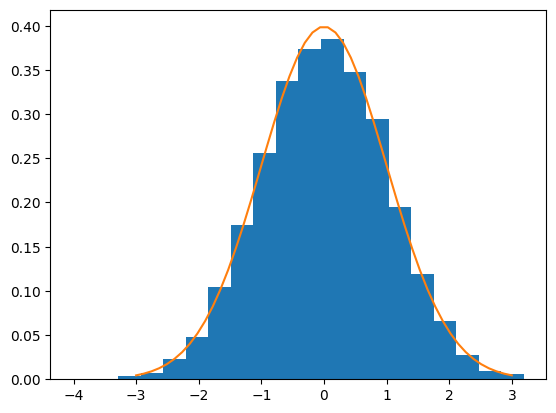

In [308]:
# plotta histogram för att se om det ser bra ut
fig = plt.figure()
ax = fig.gca()
ax.hist(samples, density=True, bins=20)
ax.plot(np.linspace(-3, 3, 50), f(np.linspace(-3,3,50)))

plt.show()

In [309]:
p = np.sum(samples > 2) / num_samples
print(f"P(Z>2) = {p:.3f}")

P(Z>2) = 0.022


In [310]:
# Del b). Vi ska beräkna P(X > 3.7) om X är Gamma(1,1) <=> Exp(1)
x_rv = stats.gamma(a=1, scale=1) # detta är lite fuskigt, kan t.ex. använda inversionsmetoden
num_samples = 100000
print(f"P(X > 3.7) = {np.sum(x_rv.rvs(size=num_samples) > 3.7) / num_samples}")

P(X > 3.7) = 0.02464


In [311]:
# exakt värde a s.a. P(X > a) = 0.025 ges av:
print(-np.log(0.025))

3.6888794541139363


## Uppgift 10.9

In [ ]:
# a) sätt upp aposteriorifördelningen (onormaliserad) OBS viktigt att koda in stödet, i detta fall theta tillhör [0, 1].

def posterior(theta):
    return (np.pow(theta, 18) * np.pow(1- theta, 5) + np.pow(1-theta, 17) * np.pow(theta, 6)) * (theta > 0) * (theta < 1)

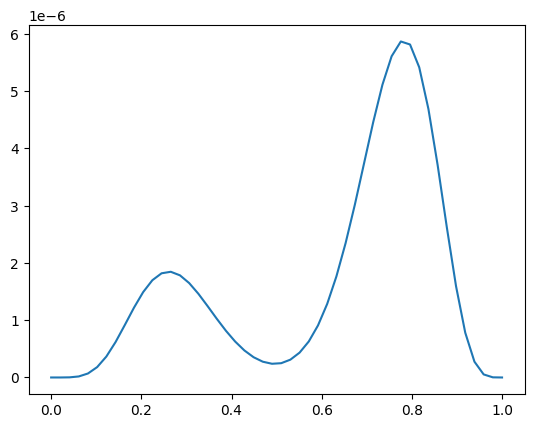

In [253]:
theta_vals = np.linspace(0, 1, 50)
plt.plot(theta_vals, posterior(theta_vals))

In [316]:
delta = 0.2
start = 0.2
n = 10000

sample_chain = np.zeros(n)
sample_chain[0] = start
jump_dist = stats.norm(loc=0, scale=delta) # hoppfördelning 
u_rv = stats.uniform()

# metropolisalgoritmen
for i in range(n-1):
    y = sample_chain[i] + jump_dist.rvs()
    r = posterior(y) / posterior(sample_chain[i])
    u = u_rv.rvs()
    if u <= min(r, 1):
        sample_chain[i+1] = y
    else:
        sample_chain[i+1] = sample_chain[i]

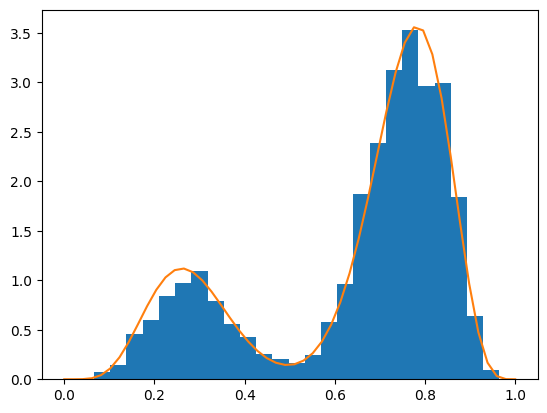

In [ ]:
# visualisera vår sampling genom att göra ett histogram av stickprovet i samma plot som fördelningen vi försöker simulera från. np.trapezoid har använt för att normalisera målfördelningens täthet så att den får samma höjd som och därmed blir jämförbar med histogrammet.
fig = plt.figure()
ax = fig.gca()

ax.hist(sample_chain, density=True, bins=25)
ax.plot(theta_vals, posterior(theta_vals) / np.trapezoid(posterior(theta_vals), theta_vals))
plt.show()

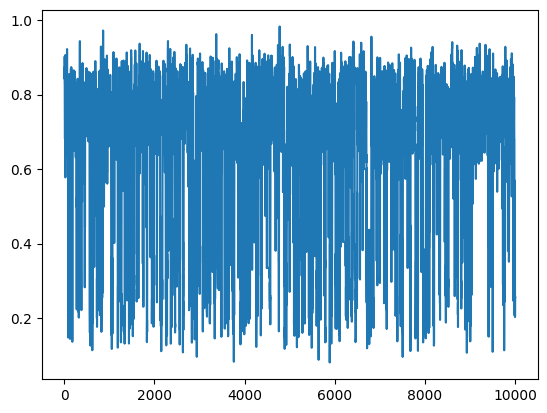

In [299]:
plt.plot(sample_chain)

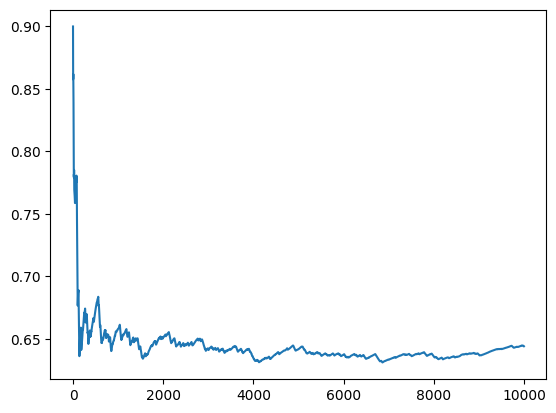

In [ ]:
# plotta kumulativt medelvärde
n_vals = np.arange(1, n+1)
plt.plot(np.cumsum(sample_chain) / n_vals)

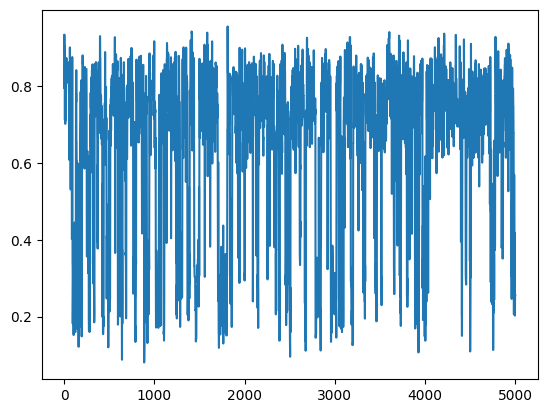

In [ ]:
# kapa början av kedjan "uppvärmningsfasen" för att säkerställa att våra samples följer den eftertraktade fördelningen så gott som möjligt
warm_up = n//2
samples = sample_chain[warm_up:]
plt.plot(samples)

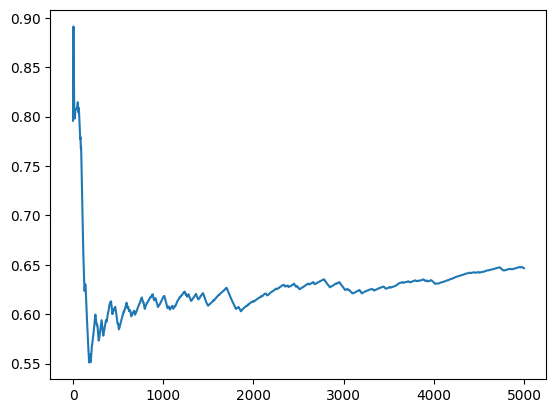

In [ ]:
# plotta kumulativt medelvärde
plt.plot(np.cumsum(samples) / np.arange(1, len(samples)+1))

In [ ]:
# del c). Approximera aposterioriväntevärde och aposteriorimedian

print(f"Posterior mean = {np.mean(samples)}")
print(f"Posterior median = {np.sort(samples)[len(samples) // 2]}")

Posterior mean = 0.6465743101746488
Posterior median = 0.731934529155727
